# 23 &middot; Fast Complementary Dynamics &mdash; secondary motion that never fights the rig

An animator poses a character with a **rig**: a few handles driving a smooth Linear Blend
Skinning (LBS) deformation. *Complementary dynamics* (Zhang et al. 2020) layers physical
secondary motion &mdash; jiggle, sag, follow-through &mdash; **on top** of that rig, under one
rule: the simulation may never reproduce a motion the rig can already make itself.

Split every vertex's displacement into a rig part and a complementary part,

$$
u \;=\; \underbrace{u_r}_{\text{rig (the animator)}} \;+\; \underbrace{u_c}_{\text{complementary (the physics)}},
$$

and constrain the complementary part to be **orthogonal to the rig**:

$$
\boxed{\,D\,M\,J^{\top}\,u_c \;=\; 0\,}.
$$

* $J$ &mdash; the LBS Jacobian of the rig. Its columns span every displacement the handles can
  produce, i.e. the **control space**.
* $M$ &mdash; the mass matrix, so "orthogonal" is measured in the physical *momentum* inner product:
  $u_c$ carries no momentum that the rig already accounts for.
* $D$ &mdash; a diagonal **momentum-leaking** field. Where $D=1$ momentum is conserved against the
  rig; where $D\to 0$ momentum is allowed to *leak*, letting that tissue ride along with the
  handle instead of resisting it.

We build this twice. First a **full-order** solver, to watch the constraint do its job. Then the
**fast** version of *Fast Complementary Dynamics via Skinning Eigenmodes* (Benchekroun et al.,
SIGGRAPH 2023), which makes it real-time with two `simkit` ingredients: **rig-orthogonal skinning
eigenmodes** and **rotation clustering**.

In [1]:
%matplotlib inline
import time, warnings
import numpy as np
import scipy as sp
import scipy.sparse as sps
import igl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import utils
from simkit import (massmatrix, deformation_jacobian, lbs_jacobian, volume,
                    ympr_to_lame, polar_svd, orthonormalize,
                    project_into_subspace, cluster_grouping_matrices)
from simkit.diffuse_field import diffuse_field
from simkit.normalize_and_center import normalize_and_center
from simkit.lbs_weight_space_constraint import lbs_weight_space_constraint
from simkit.skinning_eigenmodes import skinning_eigenmodes
from simkit.spectral_cubature import spectral_cubature
from simkit.solvers import block_coord
warnings.filterwarnings("ignore"); np.seterr(all="ignore")

YM, RHO, DT = 1e5, 1e3, 1e-2          # Young's modulus, density, timestep
RIG_C, FULL_C, RED_C = "#d62728", "#1f77b4", "#2ca02c"   # rig / full / reduced colors

## Setup: the beam, the shared FEM operators, and a side-by-side renderer

Not the focus of the tutorial. These are the standard ARAP/FEM operators of tutorials 1&ndash;3
(mass matrix, deformation Jacobian, ARAP stiffness), the metronome **beam** mesh, the rig-pose
solve, and a small helper that animates several deforming meshes side by side. Run it, then skip
to the next cell.

In [2]:
def beam(width=40, height=5, thickness=0.1):
    """A thin vertical beam (a metronome arm), centered and normalized."""
    X, T = igl.triangulated_grid(width, height)
    X[:, 1] *= thickness
    Y = X.copy(); X[:, 0] = -Y[:, 1]; X[:, 1] = Y[:, 0]
    return normalize_and_center(X), T

def elastic_operators(X, T):
    """Standard ARAP/FEM operators (covered in tutorials 1-3)."""
    dim = X.shape[1]
    Mv  = sps.kron(massmatrix(X, T, rho=RHO), sps.identity(dim)).tocsc()  # mass
    G   = deformation_jacobian(X, T)                                      # x -> per-elem F
    mu, _ = ympr_to_lame(YM, 0); vol = volume(X, T)
    AMu  = sps.diags((mu * vol).flatten())                               # elastic weights
    AMue = sps.kron(AMu, sps.identity(dim * dim))
    L    = (G.T @ AMue @ G).tocsc()                                       # ARAP stiffness
    return dict(Mv=Mv, G=G, AMue=AMue, L=L, AMu=AMu, dim=dim)

def rig_rest(J, Mv, X):
    """Rig parameters p whose pose J p best matches the rest shape."""
    JMJ, JMy = J.T @ Mv @ J, J.T @ Mv @ X.reshape(-1, 1)
    return project_into_subspace(X.reshape(-1, 1), J, M=Mv, BMB=JMJ, BMy=JMy)

# left/right sweep of the handle's x-translation (the only thing the animator does)
PERIOD, AMP = 80, 3.0
def handle(p0, i):
    p = p0.copy(); p[-2] = AMP * np.sin(2 * np.pi * i / PERIOD); return p

def thin(states, target=110):
    k = max(1, len(states) // target)
    return states[::k]

def animate_panels(panels, *, fps=30, suptitle=None, lims=None):
    """Deforming meshes side by side, one color each. panels: list of dicts
    {states, T, title, color}. Returns (fig, anim)."""
    if lims is None:
        lims = utils.auto_limits([s for p in panels for s in p["states"]], pad=0.6)
    npan = len(panels)
    fig, axes = plt.subplots(1, npan, figsize=(5.2 * npan, 4.4), squeeze=False)
    axes = axes[0]; arts = []
    nframes = max(len(p["states"]) for p in panels)
    for ax, p in zip(axes, panels):
        utils.setup_axes(ax, lims[0], lims[1], title=p["title"])
        arts.append(utils.PolyMeshArtist(ax, p["states"][0], p["T"],
                    facecolor=p["color"], edgecolor="0.3", lw=0.5, alpha=0.95))
    def update(i):
        for art, p in zip(arts, panels):
            art.update(p["states"][min(i, len(p["states"]) - 1)])
        return ()
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    if suptitle: fig.suptitle(suptitle, fontsize=13)
    return fig, FuncAnimation(fig, update, frames=nframes, interval=1000 / fps, blit=False)

## 1 &middot; The rig: one global handle

The simplest possible rig is a **single affine handle** &mdash; one LBS bone with weight $1$
everywhere. `lbs_jacobian(X, ones)` builds its Jacobian $J$, whose $6$ columns (in 2D) span
every affine map: translation, rotation, scale, shear. The animator's pose is a vector of rig
parameters $p$, and the rigged shape is simply $x = J\,p$.

Here the animation is a metronome: sweep the handle's $x$-translation left and right. On its own
the beam stays perfectly rigid &mdash; there is no physics yet.

In [3]:
X, T = beam(); n, dim = X.shape
op = elastic_operators(X, T)
J  = lbs_jacobian(X, np.ones((n, 1)))          # control space: one global affine handle
p0 = rig_rest(J, op["Mv"], X)
print(f"mesh: {n} verts, {T.shape[0]} triangles   |   rig: J is {J.shape} -> {J.shape[1]} DOFs")

NSTEPS = 200
rig_states = [(J @ handle(p0, i)).reshape(n, dim) for i in range(NSTEPS)]

fig, anim = animate_panels(
    [dict(states=thin(rig_states), T=T, title="rig pose  $x = J\\,p$", color=RIG_C)],
    suptitle="The animator's input: a rigid beam swept left and right")
utils.show_video(fig, anim, "media/23_rig.mp4", fps=30)

mesh: 200 verts, 312 triangles   |   rig: J is (400, 6) -> 6 DOFs


## 2 &middot; Full-order complementary dynamics

Now add physics. Each timestep is a **backward-Euler** implicit step that minimizes the usual
inertia-plus-elasticity objective over the *total* position $x = J\,p_{\text{next}} + u_c$,

$$
\min_{u_c}\;\; \tfrac{1}{2h^2}\,\lVert x - y\rVert_M^2 \;+\; E_{\text{ARAP}}(x)
   \qquad\text{subject to}\qquad J^{\top} M D\, u_c = 0,
$$

where $y = x_{\text{curr}} + h\,\dot x$ is the inertial prediction. The only thing that makes this
*complementary* dynamics rather than ordinary elastodynamics is that one linear constraint.

We solve the ARAP minimization with **block coordinate descent** (tutorials 21 & 22):

* **local step** &mdash; for each triangle, the closest rotation to its current deformation gradient
  (one `polar_svd` per element);
* **global step** &mdash; a single linear solve for $u_c$. With the constraint, that solve becomes a
  **KKT system** $\begin{bmatrix} H & A^{\top}\\ A & 0\end{bmatrix}$ with $A = J^{\top} M D$. Both
  $H = L + M/h^2$ and $A$ are constant, so we **prefactor once** and reuse the factorization every
  step and every inner iteration.

The momentum-leaking field $D$ is built by diffusing a value of $1$ inward from the boundary
(`diffuse_field`) and using $1-\text{(that)}$: near the handle/boundary momentum leaks (tissue
follows the rig), deep inside it is conserved (tissue resists, producing secondary motion).

`FullCD` does all of this precompute in `__init__` and exposes a `step(...)` method.

In [4]:
class FullCD:
    """Full-order complementary dynamics: per-element rotations + a prefactored
    KKT global step enforcing the rig-orthogonality constraint  J^T M D u_c = 0."""

    def __init__(self, X, T):
        n, dim = X.shape
        op = elastic_operators(X, T)
        self.Mv, self.G, self.AMue, self.L = op["Mv"], op["G"], op["AMue"], op["L"]
        self.dim = dim

        # rig J: one global affine handle, and the rest pose that matches X
        self.J  = lbs_jacobian(X, np.ones((n, 1)))
        self.p0 = rig_rest(self.J, self.Mv, X)

        # momentum-leaking field D: ~0 near the boundary (leaks), ->1 in the interior (conserved)
        bnd  = np.unique(igl.boundary_facets(T)[0])
        leak = diffuse_field(X, T, bnd, np.ones((bnd.shape[0], 1)), dt=1, normalize=True)
        D    = sps.kron(sps.diags((1 - leak).flatten()), sps.identity(dim))

        # rig-orthogonality operator A = J^T M D, and the constant backward-Euler matrix H
        self.A = sps.csc_matrix(self.J.T @ self.Mv @ D)
        self.H = (self.L + self.Mv / DT**2).tocsc()

        # prefactor the KKT system [[H, A^T], [A, 0]] once, reuse every step / inner iter
        KKT = sps.bmat([[self.H, self.A.T],
                        [self.A, sps.csc_matrix((self.A.shape[0],) * 2)]]).tocsc()
        self.kkt = sps.linalg.factorized(KKT)
        self.nc  = self.A.shape[0]

        self.state_dim = n * dim
        self.n_rot     = T.shape[0]
        self.B         = None        # full order: u_c lives in full coordinates

    def step(self, uc, uc_dot, p, p_dot, p_next, iters=10):
        Jp = self.J @ p_next
        y  = (uc + DT * uc_dot) + self.J @ (p + DT * p_dot)      # inertial prediction

        def local(u):                                            # closest rotation, per triangle
            return polar_svd((self.G @ (Jp + u)).reshape(-1, self.dim, self.dim))[0].reshape(-1, 1)

        def glob(u, R):                                          # constrained (rig-orthogonal) solve
            E_inertia = self.Mv @ y / DT**2                      # backward-Euler inertia term
            E_elastic = self.G.T @ (self.AMue @ R)               # ARAP (local-rotation) elastic term
            E_rigpose = -self.H @ Jp                             # pin the rig pose into the rhs
            rhs = E_inertia + E_elastic + E_rigpose
            return self.kkt(np.vstack([rhs, np.zeros((self.nc, 1))]))[:uc.shape[0]]

        return block_coord(uc.copy(), glob, local, 0.0, iters)

### Rolling out a solver under the metronome rig

The roll-out is the same for both solvers: at each step, advance the handle pose, take one
implicit step for the complementary state, finite-difference the velocities, and record both the
deformed mesh and the rig-orthogonality residual $\lVert J^{\top} M D\,u_c\rVert$. For the reduced
solver the state lives in subspace coordinates $z$, so we lift $u_c = B\,z$ before measuring.

In [5]:
def run(solver, nsteps=NSTEPS):
    """Roll out a solver under the left/right handle sweep. Returns (states, violation)."""
    J, p0, B = solver.J, solver.p0, solver.B
    s = np.zeros((solver.state_dim, 1)); s_dot = np.zeros_like(s)
    p = p0.copy(); p_dot = np.zeros_like(p)
    states, viol = [], []
    for i in range(nsteps):
        p_next = handle(p0, i)
        s_new  = solver.step(s, s_dot, p, p_dot, p_next)
        s_dot  = (s_new - s) / DT; p_dot = (p_next - p) / DT
        s, p   = s_new, p_next.copy()
        uc = (B @ s) if B is not None else s                # u_c in full coordinates
        states.append((J @ p + uc).reshape(-1, dim))
        viol.append(float(np.linalg.norm(solver.A @ uc)))
    return states, viol

full = FullCD(X, T)
t0 = time.perf_counter()
full_states, full_viol = run(full)
t_full = (time.perf_counter() - t0) / NSTEPS * 1000
print(f"full-order: {t_full:.1f} ms/step, {full.n_rot} rotations/step")
print(f"max rig-orthogonality residual  ||J^T M D u_c|| = {max(full_viol):.1e}  (constraint holds)")

full-order: 5.1 ms/step, 312 rotations/step
max rig-orthogonality residual  ||J^T M D u_c|| = 1.1e-13  (constraint holds)


### Rig vs. rig + complementary

Left: the rig alone (rigid). Right: the same rig **plus** the complementary physics. The beam now
whips and trails as the handle reverses &mdash; secondary motion the animator never authored &mdash; yet
the constraint guarantees that motion adds nothing the handle could have done itself.

In [6]:
fig, anim = animate_panels([
    dict(states=thin(rig_states),  T=T, title="rig only  $J\\,p$",            color=RIG_C),
    dict(states=thin(full_states), T=T, title="rig + complementary  $J\\,p+u_c$", color=FULL_C),
], suptitle="Full-order complementary dynamics")
utils.show_video(fig, anim, "media/23_full.mp4", fps=30)

## 3 &middot; Why the full solve is slow

Two costs scale with the mesh:

1. **The local step** computes one `polar_svd` **per triangle** &mdash; thousands of tiny rotations
   every inner iteration.
2. **The global step** solves a sparse KKT system whose size is the **full vertex count** plus the
   constraint rows.

Refine the mesh and both grow. *Fast* complementary dynamics removes both dependencies with two
ideas, each one line of `simkit`.

## 4 &middot; Fast complementary dynamics

**Idea 1 &mdash; rig-orthogonal skinning eigenmodes.** Instead of solving for the full field $u_c$, restrict
it to a small subspace $u_c = B\,z$. *Skinning eigenmodes* are the natural rotation-aware modes of
the shape (tutorial 17). The trick: pass the rig-orthogonality requirement as an equality constraint
when building them (`lbs_weight_space_constraint` &rarr; `skinning_eigenmodes(..., Aeq=...)`), so that
**every column of $B$ already satisfies $J^{\top} M D\,B = 0$.** The constraint is now *structural* &mdash;
true for any $z$ &mdash; so the KKT block vanishes and the global solve shrinks to a tiny dense system.

**Idea 2 &mdash; rotation clustering.** The local step doesn't need a distinct rotation per triangle.
`spectral_cubature` groups elements that move together into a handful of **clusters**; the local step
then fits **one rotation per cluster**. `cluster_grouping_matrices` assembles the (mass-weighted)
grouping operator used in the local/global steps.

Together: the global solve is independent of mesh resolution (it is the size of the subspace), and
the local step is independent of mesh resolution (it is the number of clusters).

`ReducedCD` does both precomputes in `__init__` (subspace $B$, clusters, the tiny Cholesky factor)
and exposes the same `step(...)` interface as `FullCD`.

In [7]:
class ReducedCD:
    """Fast complementary dynamics: a rig-orthogonal skinning-eigenmode subspace
    + clustered rotations. Same step() interface as FullCD, but tiny and dense."""

    def __init__(self, X, T, k_modes=10, n_clusters=20):
        n, dim = X.shape
        op = elastic_operators(X, T)
        Mv, G, AMu, L = op["Mv"], op["G"], op["AMu"], op["L"]
        self.dim = dim

        # rig J and its rest pose
        self.J  = lbs_jacobian(X, np.ones((n, 1)))
        self.p0 = rig_rest(self.J, Mv, X)

        # momentum-leaking field D (same construction as the full-order solver)
        bnd  = np.unique(igl.boundary_facets(T)[0])
        leak = diffuse_field(X, T, bnd, np.ones((bnd.shape[0], 1)), dt=1, normalize=True)
        D    = sps.kron(sps.diags((1 - leak).flatten()), sps.identity(dim))

        # Idea 1: subspace B with rig-orthogonality  (J^T M D) B = 0  baked in
        Aeq = lbs_weight_space_constraint(X, T, (D @ Mv @ self.J).T)
        W, _E, B = skinning_eigenmodes(X, T, k_modes, Aeq=Aeq)
        self.B = orthonormalize(B, M=Mv)

        # Idea 2: cluster elements that rotate together; one rotation per cluster
        _cI, _cW, labels = spectral_cubature(X, T, W, n_clusters, return_labels=True)
        self.labels = np.asarray(labels).flatten()
        P, _Pm = cluster_grouping_matrices(self.labels, X, T)
        PAMue  = sps.kron(P @ AMu, sps.identity(dim * dim))
        self.GB = (PAMue @ G) @ self.B                       # clustered deformation operators
        self.GJ = (PAMue @ G) @ self.J

        # reduced stiffness / mass and rig-coupling blocks
        self.BLB, self.BMB = self.B.T @ L @ self.B, self.B.T @ Mv @ self.B
        self.BMJ, self.BLJ = self.B.T @ Mv @ self.J, self.B.T @ L @ self.J
        self.chol = sp.linalg.cho_factor(self.BLB + self.BMB / DT**2)   # tiny dense factor, reused

        # rig-orthogonality operator (used only to report the residual)
        self.A = sps.csc_matrix(self.J.T @ Mv @ D)
        self.state_dim = self.B.shape[1]
        self.n_rot     = P.shape[0]

    def step(self, z, z_dot, p, p_dot, p_next, iters=10):
        y = z + DT * z_dot
        q = p_next - (p + DT * p_dot)

        def local(zz):                                       # one rotation per cluster
            return polar_svd((self.GB @ zz + self.GJ @ p_next).reshape(-1, self.dim, self.dim))[0].reshape(-1, 1)

        def glob(zz, R):                                     # dense solve in subspace coordinates
            E_inertia = self.BMB @ y / DT**2                 # reduced inertia term
            E_rigvel  = -self.BMJ @ q / DT**2                # rig momentum coupling
            E_elastic = self.GB.T @ R                        # clustered ARAP elastic term
            E_rigpose = -self.BLJ @ p_next                   # rig pose coupling
            rhs = E_inertia + E_rigvel + E_elastic + E_rigpose
            return sp.linalg.cho_solve(self.chol, rhs)

        return block_coord(z.copy(), glob, local, 0.0, iters)

In [8]:
red = ReducedCD(X, T)
print(f"subspace B: {red.B.shape}  ->  {red.state_dim} DOFs")
print(f"structural rig-orthogonality  ||(J^T M D) B|| = {np.linalg.norm((red.A @ red.B)):.1e}")
print(f"rotation clusters: {red.n_rot}  (vs {T.shape[0]} triangles)")

t0 = time.perf_counter()
red_states, _ = run(red)
t_red = (time.perf_counter() - t0) / NSTEPS * 1000
print(f"reduced: {t_red:.2f} ms/step   ->   {t_full / t_red:.1f}x faster than full-order")

subspace B: (400, 60)  ->  60 DOFs
structural rig-orthogonality  ||(J^T M D) B|| = 2.4e-08
rotation clusters: 20  (vs 312 triangles)
reduced: 0.68 ms/step   ->   7.5x faster than full-order


### The rotation clusters

Each color is one cluster of triangles that share a single rotation in the local step. A few dozen
clusters capture the bending of the whole beam, so the local step cost no longer depends on how
finely the beam is meshed.

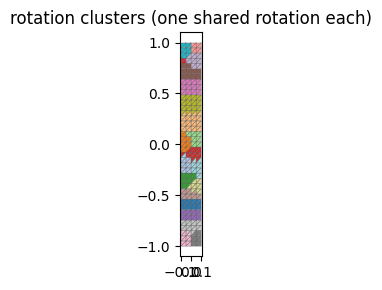

In [9]:
fig, ax = plt.subplots(figsize=(8, 3))
utils.setup_axes(ax, title="rotation clusters (one shared rotation each)", grid=False)
ax.tripcolor(X[:, 0], X[:, 1], T, facecolors=red.labels.astype(float),
             cmap="tab20", edgecolors="0.4", linewidth=0.3)
ax.set_aspect("equal"); fig.tight_layout(); plt.show()

## 5 &middot; Rig vs. full vs. reduced

The reduced solve reproduces the full-order secondary motion closely &mdash; the same whip and trail &mdash;
while solving a system that is orders of magnitude smaller.

In [10]:
fig, anim = animate_panels([
    dict(states=thin(rig_states),  T=T, title="rig",                  color=RIG_C),
    dict(states=thin(full_states), T=T, title=f"full  ({full.n_rot} rot, {full.state_dim} DOF)", color=FULL_C),
    dict(states=thin(red_states),  T=T, title=f"reduced  ({red.n_rot} rot, {red.state_dim} DOF)", color=RED_C),
], suptitle="Complementary dynamics: full-order vs. fast (skinning eigenmodes)")
utils.show_video(fig, anim, "media/23_compare.mp4", fps=30)

## 6 &middot; Timing: how the gap grows with resolution

The reduced solver's cost is set by the subspace size and the cluster count &mdash; **both fixed**, both
independent of the mesh. So as we refine the beam, the full-order cost climbs while the reduced cost
stays nearly flat, and the speedup widens.

We sweep a handful of mesh resolutions explicitly, building a fresh `FullCD` and `ReducedCD` at each
one and timing the median per-step cost.

  200 verts /   312 tris:  full    5.0 ms   reduced  0.67 ms   (  7.5x)


  490 verts /   828 tris:  full   12.7 ms   reduced  0.67 ms   ( 19.0x)


  800 verts /  1386 tris:  full   20.3 ms   reduced  0.68 ms   ( 30.0x)


 1260 verts /  2224 tris:  full   32.2 ms   reduced  0.67 ms   ( 47.9x)


 1800 verts /  3222 tris:  full   46.3 ms   reduced  0.67 ms   ( 69.0x)


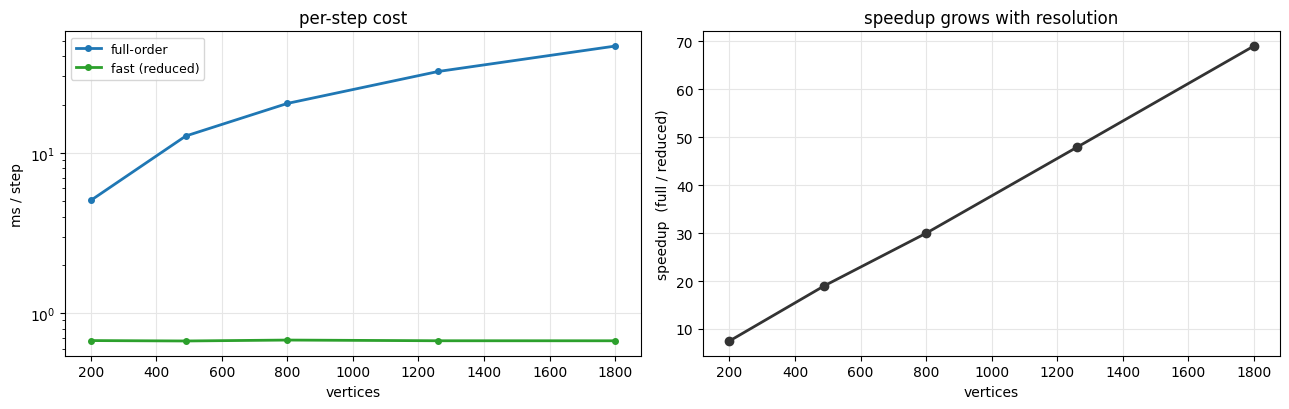

In [11]:
def bench(solver, warmup=2, n=12):
    """Median ms/step for one solver under the metronome rig (after warmup)."""
    J, p0 = solver.J, solver.p0
    s = np.zeros((solver.state_dim, 1)); s_dot = np.zeros_like(s)
    p = p0.copy(); p_dot = np.zeros_like(p); ts = []
    for i in range(warmup + n):
        p_next = handle(p0, i)
        t0 = time.perf_counter()
        s_new = solver.step(s, s_dot, p, p_dot, p_next)
        dt = time.perf_counter() - t0
        s_dot = (s_new - s) / DT; p_dot = (p_next - p) / DT; s, p = s_new, p_next.copy()
        if i >= warmup: ts.append(dt)
    return 1000 * np.median(ts)

res_list = [(40, 5), (70, 7), (100, 8), (140, 9), (180, 10)]
verts, t_fulls, t_reds = [], [], []
for (w, h) in res_list:
    Xr, Tr = beam(w, h)
    tf = bench(FullCD(Xr, Tr))
    tr = bench(ReducedCD(Xr, Tr))
    verts.append(Xr.shape[0]); t_fulls.append(tf); t_reds.append(tr)
    print(f"{Xr.shape[0]:5d} verts / {Tr.shape[0]:5d} tris:  full {tf:6.1f} ms   reduced {tr:5.2f} ms   ({tf/tr:5.1f}x)")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.2))
utils.line_plot(verts, {"full-order": t_fulls, "fast (reduced)": t_reds},
                xlabel="vertices", ylabel="ms / step", markers=True, logy=True,
                colors={"full-order": FULL_C, "fast (reduced)": RED_C}, ax=axL)
axL.set_title("per-step cost")
axR.plot(verts, np.array(t_fulls) / np.array(t_reds), "-o", color="0.2", lw=2)
axR.set_xlabel("vertices"); axR.set_ylabel("speedup  (full / reduced)")
axR.set_title("speedup grows with resolution"); axR.grid(True, color="0.9")
fig.tight_layout(); plt.show()

## Takeaways

* **Complementary dynamics = ordinary elastodynamics + one constraint.** Forcing the secondary
  motion to be rig-orthogonal, $J^{\top} M D\,u_c = 0$, is the whole idea. The momentum-leaking field
  $D$ chooses where tissue rides with the rig versus resists it.
* **Full-order makes the constraint explicit** through a KKT global step in an ARAP local/global
  solve &mdash; the same block coordinate descent as tutorials 21 & 22, with one extra constraint block.
  Correct, but its cost scales with the mesh.
* **Fast complementary dynamics moves both costs off the mesh.** A *rig-orthogonal skinning-eigenmode*
  subspace makes the constraint structural (so the global solve is tiny and unconstrained), and
  *rotation clustering* fixes the number of local rotations. Per-step cost becomes essentially
  independent of resolution &mdash; the result reported by Benchekroun et al. (2023).
* **Everything here is one call away in `simkit`:** `lbs_jacobian`, `diffuse_field`,
  `lbs_weight_space_constraint`, `skinning_eigenmodes`, `spectral_cubature`,
  `cluster_grouping_matrices`, and `solvers.block_coord`.